In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [50]:
ALLPIX_FILE   = "allpix150V.csv"
GARFIELD_FILE = "garfield150V.csv"
SILVACO_FILE  = "silvaco150V.csv"

In [51]:
GARFIELD_CURVE = "i_gainON"
SILVACO_WIDTH_UM = 1.0

In [52]:
def load_allpix(path, col):
    allpix = np.genfromtxt(path, delimiter=",", names=True)
    (allpix.dtype.names)
    print(allpix.dtype.names)
    return allpix["t_ns"], allpix[col] # already ns / uA
    # t = allpix["t_ns"]
    # i = allpix[col] * 1e1
    # return t, i
 
def load_garfield(path, col):
    garfield = np.genfromtxt(path, delimiter=",", names=True)
    (garfield.dtype.names)
    print(garfield.dtype.names)
    return garfield["t_ns"], garfield[col] # fC/ns == uA
 
def load_silvaco(path, width_um):
    silvaco = np.genfromtxt(path, delimiter=",", names=True)
    print(silvaco.dtype.names)
    t_ns = silvaco["Transient_time"] * 1e9 # s -> ns
    i_uA = silvaco["Anode_Current"] * 1e6 * width_um   # A/um -> uA
    fired = np.abs(i_uA) > 10 * np.abs(i_uA[0])
    baseline = i_uA[~fired].mean() if (~fired).any() else 0.0
    return t_ns, -(i_uA - baseline)
 
curves = {}
t, i = load_allpix(ALLPIX_FILE, "both_raw_uA")
curves["Allpix (pad, low-pass)"] = (t, i, "tab:green")
t, i = load_garfield(GARFIELD_FILE, GARFIELD_CURVE)
curves[f"Garfield++ ({GARFIELD_CURVE})"] = (t, i, "tab:red")
t, i = load_silvaco(SILVACO_FILE, SILVACO_WIDTH_UM)
curves["Silvaco (anode, sign-flipped)"] = (t, i, "tab:blue")
 
# collected charge: uA x ns = fC, directly comparable across simulators
_trap = getattr(np, "trapezoid", None) or np.trapz
print(f"{'curve':35s} {'peak [uA]':>12s} {'charge [fC]':>12s}")
for name, (t, i, c) in curves.items():
    print(f"{name:35s} {i[np.argmax(np.abs(i))]:12.3f} "
          f"{_trap(i, t):12.3f}")


('t_ns', 'left_raw_uA', 'left_fullBW_uA', 'left_reducedBW_uA', 'right_raw_uA', 'right_fullBW_uA', 'right_reducedBW_uA', 'both_raw_uA', 'both_fullBW_uA', 'both_reducedBW_uA')
('bin', 't_ns', 'i_gainON', 'i_gainOFF')
('Transient_time', 'Anode_Voltage', 'Anode_Int_Voltage', 'Anode_Current', 'Cathode_Voltage', 'Cathode_Int_Voltage', 'Cathode_Current', 'Substrate_Voltage', 'Substrate_Int_Voltage', 'Substrate_Current', 'SEU_Track_Charge', 'SEU_Track_Cumulative_Charge', 'SEU_Track_Generation_Rate')
curve                                  peak [uA]  charge [fC]
Allpix (pad, low-pass)                    -5.444       -3.860
Garfield++ (i_gainON)                    -10.079       -9.151
Silvaco (anode, sign-flipped)             -4.987       -4.586


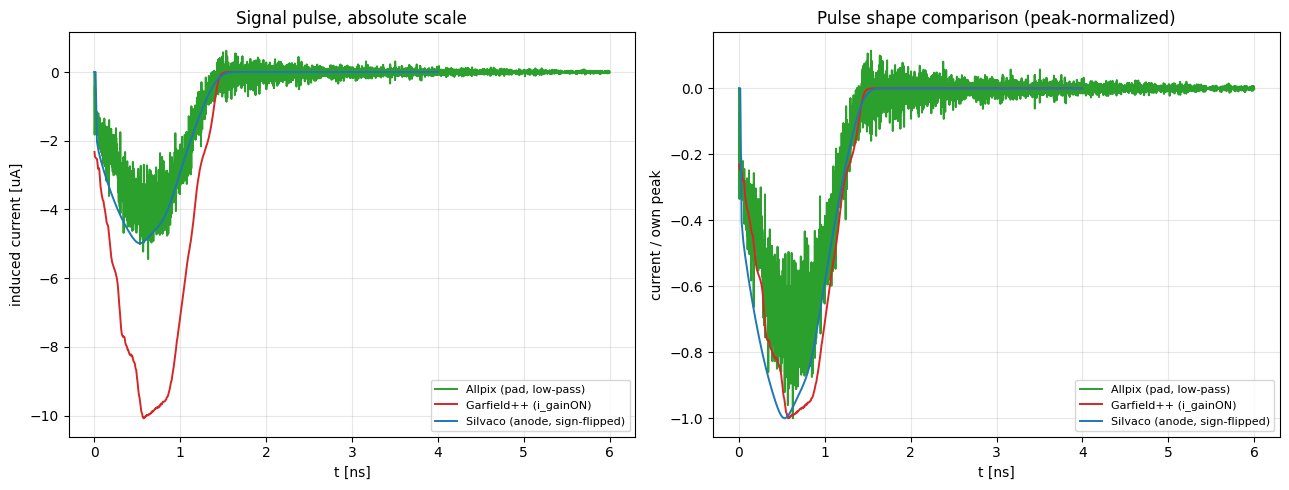

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
ax = axes[0]
for name, (t, i, c) in curves.items():
    ax.plot(t, i, color=c, lw=1.4, label=name)
ax.set_xlabel("t [ns]")
ax.set_ylabel("induced current [uA]")
ax.set_title("Signal pulse, absolute scale")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
for name, (t, i, c) in curves.items():
    peak = np.max(np.abs(i))
    ax.plot(t, i / peak if peak > 0 else i, color=c, lw=1.4, label=name)
ax.set_xlabel("t [ns]")
ax.set_ylabel("current / own peak")
ax.set_title("Pulse shape comparison (peak-normalized)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig("signal_comparison.png", dpi=150)
plt.show()
